# Episode 7 — ML Optimizers

**Instructor notebook** · run top-to-bottom before recording.

Implement **SGD → Momentum → RMSProp → AdamW → Muon** as pure-JAX `NamedTuple`s
(`init` + `__call__`). Model, data, and the train loop live in [`helpers.py`](./helpers.py);
**you write the optimizers here.**

| | |
|---|---|
| **Chapter** | 2.2 · Part II — GPT-2 & single-GPU training |
| **Prereq** | [Episode 6](../ep06/solution.ipynb) |
| **Next** | Episode 8 — Memory & mixed precision |

**Visual intuition:**

1. [Why Momentum Really Works](https://distill.pub/2017/momentum/) — Distill on momentum, step-size, curvature
2. [Gradient Optimizer Comparison](https://www.corefranciscopark.com/blog/gradient-optimizer-comparison) — race optimizers on classic loss landscapes


## Setup

[`helpers.py`](./helpers.py) provides Tiny Shakespeare loading, the GPT model, `train(...)`,
and Muon utilities (`map_leaves`, `newton_schulz5`).


In [11]:
import os
import sys
from pathlib import Path
from typing import Any, NamedTuple

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

_cwd = Path.cwd().resolve()
_ep = _cwd if (_cwd / "helpers.py").is_file() else _cwd / "ep07"
if str(_ep) not in sys.path:
    sys.path.insert(0, str(_ep))

import jax
import jax.numpy as jnp
import jax.random as jr
from IPython.display import Image, display
from jax import Array

from helpers import (
    TransformerParams,
    count_params,
    ep07_config,
    load_corpus,
    map_leaves,
    newton_schulz5,
    train,
    train_val_split,
)

Params = Any

print("JAX devices:", jax.devices())

JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]


## Data + model

Tiny Shakespeare, ~16M GPT (4×256×8).


In [12]:
corpus_n, enc = load_corpus()
train_n, val_n = train_val_split(corpus_n, val_frac=0.1)
config = ep07_config(vocab_dim=enc.n_vocab, dropout_rate=0.2)

key = jr.key(0)
key, key_init = jr.split(key)
params_probe = TransformerParams.init(key_init, config)

print(f"corpus: {corpus_n.shape[0]:,} tokens (train {train_n.shape[0]:,} / val {val_n.shape[0]:,})")
print(f"config: {config}")
print(f"model:  {count_params(params_probe) / 1e6:.2f}M params")

corpus: 338,025 tokens (train 304,223 / val 33,802)
config: GPTConfig(vocab_dim=50257, max_ctx=256, n_layers=4, n_heads=8, hidden=256, mlp_mult=4, dropout_rate=0.2)
model:  16.09M params


## Optimizer contract

Every optimizer is a `NamedTuple` of hyperparameters with:

```python
opt_state = optimizer.init(params)                    # allocate state (or None)
params, opt_state = optimizer(params, grads, opt_state, step)  # step is 1-indexed
```

`train(..., optimizer=opt)` only needs `.name`, `.learning_rate`, `.init`, and `__call__`.


## 1. SGD

$$
\theta \leftarrow \theta - \eta\, g
$$

| Pros | Cons |
|------|------|
| Dead simple; no state; easy to reason about | Slow on ill-conditioned / sparse-grad problems |
| Strong baseline when LR is tuned (often with schedule) | Sensitive to learning rate; zigzags in narrow valleys |
| Often best *final* convergence given enough time | No per-coordinate scaling |

See also the Distill piece on why plain GD struggles with pathological curvature.


### Implement `SGD`

*(Solution below.)*


In [13]:
class SGD(NamedTuple):
    learning_rate: float = 3e-3

    @property
    def name(self) -> str:
        return "SGD"

    def init(self, params: Params) -> None:
        return None

    def __call__(
        self, params: Params, grads: Params, opt_state: None, step: Array
    ) -> tuple[Params, None]:
        del step
        new_params = jax.tree.map(
            lambda param, grad: param - self.learning_rate * grad,
            params,
            grads,
        )
        return new_params, opt_state


print(SGD())

SGD(learning_rate=0.003)


## 2. Momentum (heavy-ball)

$$
\begin{aligned}
v &\leftarrow \beta\, v + g \\
\theta &\leftarrow \theta - \eta\, v
\end{aligned}
$$

| Pros | Cons |
|------|------|
| Accelerates along consistent directions; damps oscillation | Extra state (velocity tree = params size) |
| Larger usable LR range than plain SGD | Can overshoot sharp minima if β / η too large |
| Great intuition in [Distill — Momentum](https://distill.pub/2017/momentum/) | Still no per-coordinate adaptation |

Try the Distill sliders: β near 0.99 on a skinny quadratic.


### Implement `Momentum`

*(Solution below.)*


In [ ]:
class Momentum(NamedTuple):
    learning_rate: float = 3e-3
    beta: float = 0.9

    @property
    def name(self) -> str:
        return "Momentum"

    def init(self, params: Params) -> Params:
        return jax.tree.map(jnp.zeros_like, params)

    def __call__(
        self, params: Params, grads: Params, velocity: Params, step: Array
    ) -> tuple[Params, Params]:
        del step
        velocity = jax.tree.map(
            lambda velocity_leaf, grad: self.beta * velocity_leaf + grad,
            velocity,
            grads,
        ) # velocity now a function of all prior gradients (with each each prior gradient contributing a bit less)
        params = jax.tree.map(
            lambda param, velocity_leaf: param - self.learning_rate * velocity_leaf,
            params,
            velocity,
        )
        return params, velocity
        # 2 bytes per param for weight, 2 bytes per param for gradients, 4 bytes per param for velocity (fp32)


print(Momentum())

Momentum(learning_rate=0.003, beta=0.9)


## 3. RMSProp

$$
\begin{aligned}
v &\leftarrow \rho\, v + (1-\rho)\, g^{2} \\
\theta &\leftarrow \theta - \eta\, \frac{g}{\sqrt{v}+\varepsilon}
\end{aligned}
$$

| Pros | Cons |
|------|------|
| Per-coordinate step sizes — good for sparse / varying scales | Still first-order; can be noisy |
| Stabilizes training when gradient magnitudes differ a lot | Two hyperparameters (ρ, η); ε matters numerically |
| Cheap: one second-moment tree | No momentum on the gradient itself (unlike Adam) |


### Implement `RMSProp`

*(Solution below.)*


In [15]:
class RMSProp(NamedTuple):
    learning_rate: float = 1e-3
    rho: float = 0.9
    eps: float = 1e-8

    @property
    def name(self) -> str:
        return "RMSProp"

    def init(self, params: Params) -> Params:
        return jax.tree.map(jnp.zeros_like, params)

    def __call__(
        self, params: Params, grads: Params, second_moment: Params, step: Array
    ) -> tuple[Params, Params]:
        del step
        second_moment = jax.tree.map(
            lambda moment, grad: self.rho * moment
            + (1.0 - self.rho) * jnp.square(grad), # not as sensitive to changing signs (cares about magnitude, better when gradient magnitudes differ a lot, since squaring grads removes sign)
            second_moment,
            grads,
        )
        params = jax.tree.map(
            lambda param, grad, moment: param
            - self.learning_rate * grad / (jnp.sqrt(moment) + self.eps),
            params,
            grads,
            second_moment,
        )
        return params, second_moment


print(RMSProp())

RMSProp(learning_rate=0.001, rho=0.9, eps=1e-08)


## 4. AdamW

**Adam core** (bias-corrected moments), then **decoupled weight decay**
$\theta \leftarrow \theta\,(1-\eta\lambda)$ *before* the Adam step (not L2 folded into $g$):

$$
\begin{aligned}
m &\leftarrow \beta_1 m + (1-\beta_1)\, g \\
v &\leftarrow \beta_2 v + (1-\beta_2)\, g^{2} \\
\hat{m} &= \frac{m}{1-\beta_1^{t}},\quad
\hat{v} = \frac{v}{1-\beta_2^{t}} \\
\theta &\leftarrow \theta\,(1-\eta\lambda)
         - \eta\, \frac{\hat{m}}{\sqrt{\hat{v}}+\varepsilon}
\end{aligned}
$$

| Pros | Cons |
|------|------|
| Default for transformers; robust across LRs | 2× moment memory vs SGD |
| Combines momentum + RMSProp-style scaling | Can under-regularize if you use L2-in-loss instead of decoupled decay |
| Bias correction helps early training | Still diagonal — ignores matrix structure of weight grads |
| Decoupled decay usually beats “Adam + L2” | Easy to overfit tiny corpora without dropout / schedules |

**Pretraining tip:** lock in peak LR (and the warmup → decay schedule) on short ablations *before* the long run. Once cosine/linear decay is underway, bumping LR mid-flight usually destabilizes Adam’s moment scales — treat a bad peak LR as a restart, not a mid-run tweak.


### Implement `AdamState` + `AdamW`

`step` is **1-indexed** (matches `train`).

*(Solution below.)*


In [ ]:
class AdamState(NamedTuple):
    first_moment: Params
    second_moment: Params


class AdamW(NamedTuple):
    learning_rate: float = 1e-4
    beta1: float = 0.9
    beta2: float = 0.999
    eps: float = 1e-8
    weight_decay: float = 0.1

    @property
    def name(self) -> str:
        return "AdamW"

    def init(self, params: Params) -> AdamState:
        zeros = jax.tree.map(jnp.zeros_like, params)
        return AdamState(first_moment=zeros, second_moment=zeros)

    def __call__(
        self, params: Params, grads: Params, state: AdamState, step: Array
    ) -> tuple[Params, AdamState]:
        step_count = jnp.asarray(step, dtype=jnp.float32)

        first_moment = jax.tree.map(
            lambda moment, grad: self.beta1 * moment + (1.0 - self.beta1) * grad,
            state.first_moment,
            grads,
        )
        second_moment = jax.tree.map(
            lambda moment, grad: self.beta2 * moment
            + (1.0 - self.beta2) * jnp.square(grad),
            state.second_moment,
            grads,
        )

        first_hat = jax.tree.map(
            lambda moment: moment / (1.0 - self.beta1**step_count),
            first_moment,
        )
        second_hat = jax.tree.map(
            lambda moment: moment / (1.0 - self.beta2**step_count),
            second_moment,
        )

        params = jax.tree.map(
            lambda param, first, second: param
            * (1.0 - self.learning_rate * self.weight_decay)
            - self.learning_rate * first / (jnp.sqrt(second) + self.eps),
            params,
            first_hat,
            second_hat,
        )
        return params, AdamState(
            first_moment=first_moment, second_moment=second_moment
        )
# 2 buffers per param, fp32 for moment1, fp32 for moment2, now 1 param ---> 2 bytes for weights, 2 bytes for grads (BF16), 4 bytes for moment1, 4 bytes for moment2 (fp32)

print(AdamW())

AdamW(learning_rate=0.0001, beta1=0.9, beta2=0.999, eps=1e-08, weight_decay=0.1)


## 5. Muon

For **2D** weights: momentum, then Newton–Schulz orthogonalization
(`newton_schulz5` ≈ nearest semi-orthogonal matrix $\approx UV^{\top}$ from the SVD).
Scale by $\sqrt{\max(1,\mathrm{rows}/\mathrm{cols})}$. **1D** params fall back to Adam.

$$
\begin{aligned}
B &\leftarrow \mu B + (1-\mu)\, G \\
O &\leftarrow \mathrm{NewtonSchulz5}(B)
          \cdot \sqrt{\max\!\bigl(1,\, m/n\bigr)} \\
W &\leftarrow W\,(1-\eta\lambda) - \eta\, O
\end{aligned}
$$

where $W\in\mathbb{R}^{m\times n}$. Ortho target:

$$
\mathrm{Ortho}(G)
= \arg\min_O
\bigl\{\|O-G\|_F :
O^{\top}O=I \;\text{or}\; OO^{\top}=I\bigr\}
$$

Helpers you should call: `newton_schulz5`, `map_leaves`.

| Pros | Cons |
|------|------|
| Strong sample efficiency on hidden matrices (NanoGPT / LLM speedruns) | Only for 2D weights — need Adam (or similar) for embeddings / vectors |
| Orthogonal updates have stable spectral norm | Extra matmuls (NS steps) → slower than AdamW per step |
| Often less LR retuning when scaling width | Newer; fewer battle-tested recipes than AdamW |
| Pair with Distill/landscape demos for geometric intuition | Easy to overfit tiny data if LR is too aggressive |


### Implement `MuonState` + `Muon`

*(Solution below.)*


In [17]:
class MuonState(NamedTuple):
    velocity: Params
    first_moment: Params
    second_moment: Params


class Muon(NamedTuple):
    learning_rate: float = 0.02
    adam_lr: float = 1e-4
    momentum: float = 0.95
    weight_decay: float = 0.0
    nesterov: bool = True
    ns_steps: int = 5
    beta1: float = 0.9
    beta2: float = 0.999
    eps: float = 1e-8

    @property
    def name(self) -> str:
        return "Muon"

    def init(self, params: Params) -> MuonState:
        zeros = jax.tree.map(jnp.zeros_like, params)
        return MuonState(velocity=zeros, first_moment=zeros, second_moment=zeros)

    def __call__(
        self, params: Params, grads: Params, state: MuonState, step: Array
    ) -> tuple[Params, MuonState]:
        step_count = jnp.asarray(step, dtype=jnp.float32)
        lr, adam_lr, beta = self.learning_rate, self.adam_lr, self.momentum
        wd, ns_steps, nesterov = self.weight_decay, self.ns_steps, self.nesterov
        beta1, beta2, eps = self.beta1, self.beta2, self.eps

        def update_leaf(param, grad, velocity, first_moment, second_moment):
            if grad.ndim == 2:
                new_velocity = beta * velocity + (1.0 - beta) * grad
                buf = (
                    beta * new_velocity + (1.0 - beta) * grad
                    if nesterov
                    else new_velocity
                )
                update = newton_schulz5(buf, steps=ns_steps)
                scale = jnp.sqrt(
                    jnp.maximum(1.0, param.shape[0] / param.shape[1])
                ).astype(param.dtype)
                update = update * scale
                new_param = param * (1.0 - lr * wd) - lr * update
                return new_param, new_velocity, first_moment, second_moment

            new_first = beta1 * first_moment + (1.0 - beta1) * grad
            new_second = beta2 * second_moment + (1.0 - beta2) * jnp.square(grad)
            first_hat = new_first / (1.0 - beta1**step_count)
            second_hat = new_second / (1.0 - beta2**step_count)
            new_param = param * (1.0 - adam_lr * wd) - adam_lr * first_hat / (
                jnp.sqrt(second_hat) + eps
            )
            return new_param, velocity, new_first, new_second

        new_params, new_velocity, new_first, new_second = map_leaves(
            update_leaf,
            params,
            grads,
            state.velocity,
            state.first_moment,
            state.second_moment,
        )
        return new_params, MuonState(
            velocity=new_velocity,
            first_moment=new_first,
            second_moment=new_second,
        )


print(Muon())

Muon(learning_rate=0.02, adam_lr=0.0001, momentum=0.95, weight_decay=0.0, nesterov=True, ns_steps=5, beta1=0.9, beta2=0.999, eps=1e-08)


## Smoke test

Short AdamW run to confirm your optimizer plugs into `train`.

*(Solution below.)*


In [18]:
params = TransformerParams.init(key_init, config)
key, key_smoke = jr.split(key)
_params, smoke_hist = train(
    optimizer=AdamW(learning_rate=1e-4, weight_decay=0.1),
    params=params,
    config=config,
    train_corpus=train_n,
    val_corpus=val_n,
    key=key_smoke,
    n_steps=50,
    n_batch=64,
    n_seq=128,
    log_every=25,
)
print("smoke val losses:", [f"{v:.3f}" for v in smoke_hist.val_loss])

[AdamW] training 50 steps (batch=64, seq=128, ~0.4M tokens, lr=0.0001, dropout=0.2) …
  step    1  train_loss 10.8595  val_loss 10.4824  val_ppl 35683.0
  step   25  train_loss 9.8867  val_loss 9.3225  val_ppl 11187.1
  step   50  train_loss 8.9466  val_loss 8.4607  val_ppl 4725.4
smoke val losses: ['10.482', '9.323', '8.461']


## Curves + interactive demos

Reference LM sweep (precomputed). For *geometry*, prefer the links in the intro.

![Optimizer curves](./optimizer_curves.png)


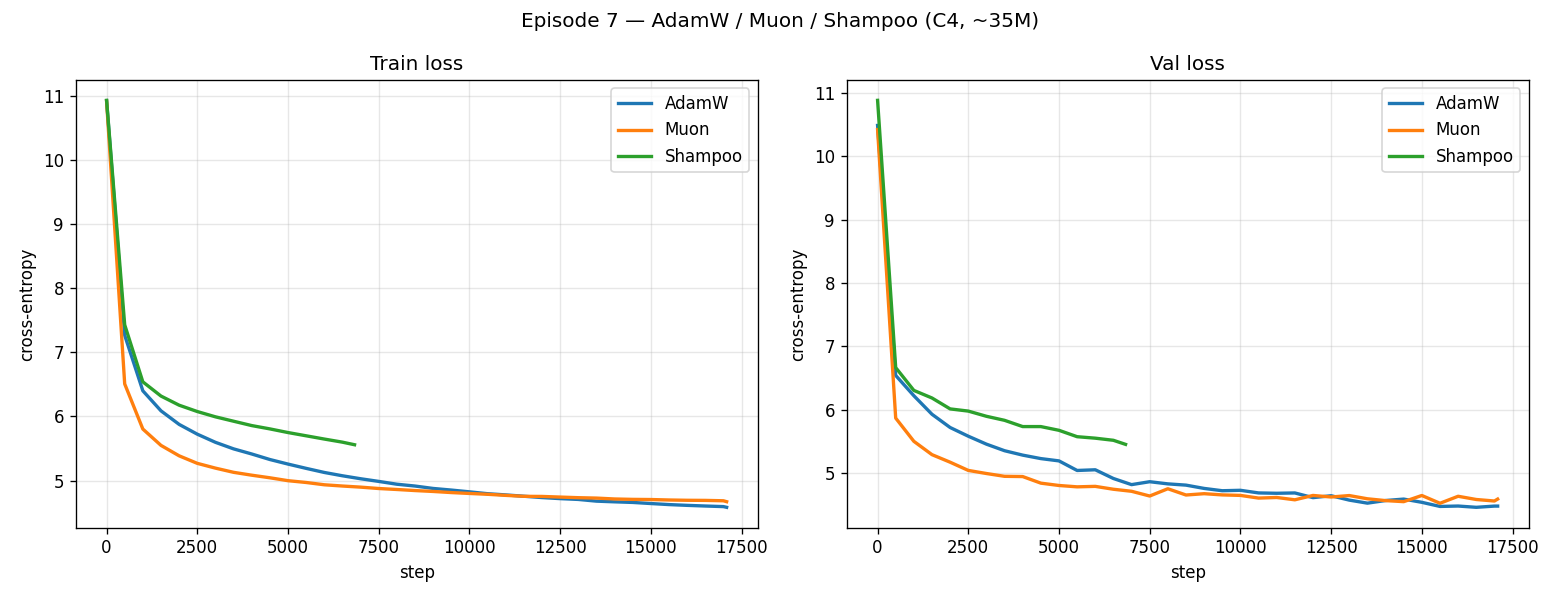

In [19]:
display(Image(filename=str(_ep / "optimizer_curves.png")))

## Takeaways

1. **SGD → Momentum** adds velocity; read [Distill](https://distill.pub/2017/momentum/).
2. **RMSProp / AdamW** add diagonal second-moment scaling (+ decay for AdamW).
3. **Muon** orthogonalizes *matrix* momentum updates; 1D params stay on Adam.
4. Same train loop for all: implement `init` + `__call__`, pass `optimizer=` into `train`.
5. Race them visually: [Gradient Optimizer Comparison](https://www.corefranciscopark.com/blog/gradient-optimizer-comparison).


---

## Exercise

1. Smoke-test `Muon()` for 50 steps (same `train(...)` call as AdamW).
2. In the [landscape demo](https://www.corefranciscopark.com/blog/gradient-optimizer-comparison), Rosenbrock + all opts — who overshoots?
3. From Distill: for fixed α, how should optimal β change as curvature λ grows?

*(Solution below.)*


In [ ]:
params = TransformerParams.init(key_init, config)
key, key_muon = jr.split(key)
_params, muon_hist = train(
    optimizer=Muon(learning_rate=0.02, adam_lr=1e-4, weight_decay=0.01),
    params=params,
    config=config,
    train_corpus=train_n,
    val_corpus=val_n,
    key=key_muon,
    n_steps=50,
    n_batch=64,
    n_seq=128,
    log_every=25,
)
print("muon val losses:", [f"{v:.3f}" for v in muon_hist.val_loss])

[Muon] training 50 steps (batch=64, seq=128, ~0.4M tokens, lr=0.02, dropout=0.2) …
  step    1  train_loss 10.8590  val_loss 10.2385  val_ppl 27958.0
  step   25  train_loss 6.9842  val_loss 5.8991  val_ppl 364.7
  step   50  train_loss 5.3826  val_loss 5.6833  val_ppl 293.9
muon val losses: ['10.238', '5.899', '5.683']


: 

---

**Further reading:** [Keller Jordan — Muon](https://kellerjordan.github.io/posts/muon/) has diagrams comparing convergence speeds (SGD / Adam / Muon and friends). Also read [SOAP, Muon, and Beyond: Pushing LLM Pretraining Scales](https://arxiv.org/pdf/2607.20548) from NVIDIA.
